#**EXP NO**:QPSK
#**REG NO**:212224060266
#**NAME**:SUJITHA ESTHER S

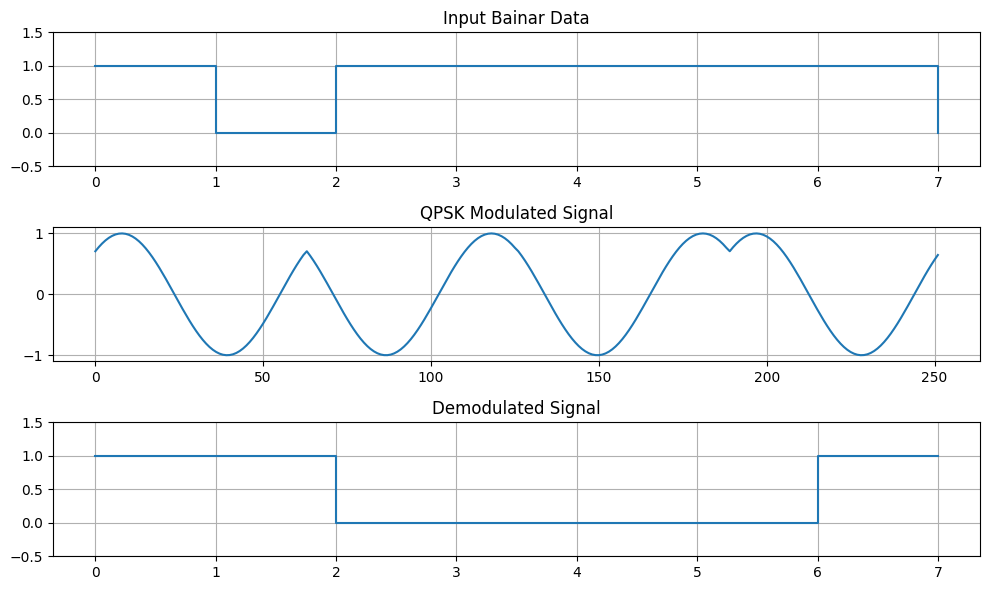

In [1]:
#QPSK
import numpy as np
import matplotlib.pyplot as plt

# Define input symbols (bit pairs)
x = ['10', '11', '11', '10']
n = len(x)
t = np.arange(-np.pi, np.pi, 0.1)

# Define phase shifted sine waves for each QPSK symbol
a = np.sin(t + (np.pi / 4))       # 00
b = np.sin(t + (3 * np.pi / 4))   # 01
c = np.sin(t + (5 * np.pi / 4))   # 10
d = np.sin(t + (7 * np.pi / 4))   # 11

# Modulate signal
mod = []
inp = []

for i in range(n):
    if x[i] == '00':
        mod.extend(a)
        inp.extend([0, 0])
    elif x[i] == '01':
        mod.extend(b)
        inp.extend([0, 1])
    elif x[i] == '10':
        mod.extend(c)
        inp.extend([1, 0])
    elif x[i] == '11':
        mod.extend(d)
        inp.extend([1, 1])

# Time base for square waves
bit_duration = len(t)
inp_time = np.repeat(np.arange(len(inp)), 2)
inp_wave = np.repeat(inp, 2)

# Demodulation
demod = []
ptr = 20  # sampling point

for i in range(n):
    val = mod[i * len(t) + ptr]
    if val <= -0.77:
        demod.extend([0, 0])
    elif -0.77 < val <= -0.63:
        demod.extend([0, 1])
    elif val >= 0.77:
        demod.extend([1, 0])
    else:
        demod.extend([1, 1])

demod_time = np.repeat(np.arange(len(demod)), 2)
demod_wave = np.repeat(demod, 2)

# Plotting
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(inp_time, inp_wave, drawstyle='steps-post')
plt.title('Input Bainar Data')
plt.ylim(-0.5, 1.5)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(mod)
plt.grid(True)
plt.title('QPSK Modulated Signal')

plt.subplot(3, 1, 3)
plt.plot(demod_time, demod_wave, drawstyle='steps-post')
plt.title('Demodulated Signal')
plt.ylim(-0.5, 1.5)
plt.tight_layout()
plt.grid(True)
plt.show()